# Lab - Case Aggregation

## Recap

Feito até aqui: Análise exploratória inicial - `lab_d1` e `real_d1`

Período recortado (primeiras 24h de ambos)
- Lab:  `2022-11-16 08:16` a `2022-11-17 08:16`
- Real: `2022-06-27 05:47` a `2022-06-28 05:47`

Volume e balanceamento de classes (Tabela 1 do paper)

- O paper reporta para o cenário real:
    - 201,673,188 (99,68%) benignos e 631,606 maliciosos (0,31%) - totalizando 202,304,794
    - Nossa fatia de 24h: ~10,85% do total do cenário, com proporção de maliciosos 0,28%

- O paper reporta para o cenário lab:
    - 482,00,616 benignos (**typo**, são 48,200,616) (96,56%) e 1,713,709 maliciosos (3,43%) - totalizando 49,914,325
    - Nossa fatia de 24h: ~7,06% do total do cenário, com proporção de maliciosos 3,73%

Campos e schema (como vieram os dados brutos)

- O dataset é armazenado como documentos Elasticsearch exportados em NDJSON
- Cada registro contém metadados do ES (`_index`, `_type`, `_id`, `_score`) e o evento real em `_source`
- Este apresenta schema heterogêneo - com 1,293 campos únicos no cenário lab e 897 no real

- Tal heterogeneidade é esperada dado que cada EventID Windows carrega campos específicos
- Sugestão de campos centrais para PM: `process_guid` (presente em 99% dos eventos)\
e `process_parent_guid`. Viabilizam rastreamento de árvores de processo sem ambiguidade de PID

- Os labels MITRE estão em `rule_technique_id` e `rule_technique_name`

Distribuição de EventType (Sysmon Registry events)

No cenário lab, os eventos de registro (Sysmon EventIDs 12/13/14) mostram:
- `CreateKey`: 69,6% - criação de chaves de registro, operação dominante
- `(sem tipo/null)`: 27,0% - eventos sem mapeamento de tipo pelo ETL
- `SetValue`: 2,4% - modificação de valores, correlacionado com persistência
- `ConnectPipe`/`CreatePipe`: 0,8% - named pipes, usados em movimento lateral
- `DeleteKey`/`DeleteValue`: 0,2% - limpeza de rastros

No cenário real essa distribuição inverte:
- (sem tipo) domina com 99,8%
- tipos válidos somam apenas 0,2%

Há uma diferença estrutural entre os dois cenários - o lab tem o Sysmon mais ativo/configurado

Labels MITRE presentes

- Para o real: 62 técnicas (na realidade 61, uma é valor errôneo/null)
- Para o lab: 58 técnias (na realidade 57, uma é valor errôneo/null)

Diferença relevante entre os dois cenários

- No cenário real, campos como `user_name` e `user_domain`\
estão presentes em apenas 0,67% dos eventos (vs. 79,18% no lab). Isso indica que a\
rede real tem muito menos eventos de autenticação identificados por usuário, o que\
impacta diretamente a estratégia de case aggregation baseada em usuário

- Outra diferença: no real, `SourceUser`/`TargetUser`/`CallTrace`/`GrantedAccess` estão em\
99,31% dos eventos (vs. 19,97% no lab), indicando que o real é dominado por eventos\
ProcessAccess (Sysmon EID 10), enquanto o lab tem maior variedade de tipos de evento.\
Isso tem implicação direta na escolha de _Activity_ para o event log de PM

## Configurações

> JupyterLab configurations

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
import pandas as pd

pd.options.display.float_format = "{:.2f}".format

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import ConnectionPatch

In [5]:
import time

In [6]:
import os

In [7]:
from pathlib import Path

In [8]:
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

> `jupysql` configurations

In [9]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = True
%config SqlMagic.displaycon = True

> `duckdb` configurations

In [10]:
import duckdb
import pandas as pd

# pasta temporária pra spill
os.makedirs(".tmp", exist_ok=True)

conn = duckdb.connect("DuckDB/lab.duckdb")

# deixar uma thread pro sistema
conn.execute("SET threads = 7")

# deixa ~3 GB de ram pro OS + Jupyter
conn.execute("SET memory_limit = '13GB'")

# spill
conn.execute("SET temp_directory = '.tmp'")

# spill no máximo 10 GB
conn.execute("SET max_temp_directory_size = '10GB'")

# lê blocos maiores do disco - bom para NVMe
conn.execute("SET checkpoint_threshold = '1GB'")

In [11]:
conn.sql("""
    SELECT name, value
    FROM duckdb_settings()
    WHERE name IN (
      'threads', 'memory_limit', 'temp_directory',
      'max_temp_directory_size', 'checkpoint_threshold'
    )
""").show()

┌─────────────────────────┬───────────┐
│          name           │   value   │
│         varchar         │  varchar  │
├─────────────────────────┼───────────┤
│ checkpoint_threshold    │ 953.6 MiB │
│ max_temp_directory_size │ 9.3 GiB   │
│ memory_limit            │ 12.1 GiB  │
│ temp_directory          │ .tmp      │
│ threads                 │ 7         │
└─────────────────────────┴───────────┘



> Criar uma view pra não ficar repetindo o caminho

In [12]:
from pathlib import Path

PAR_LAB = Path("Comiset23_Lab_Dataset/lab_d1.parquet")

WindowsPath('Comiset23_Lab_Dataset/lab_d1.parquet')

In [13]:
conn.execute(f"""
CREATE OR REPLACE VIEW lab_d1 AS
SELECT * FROM read_parquet('{PAR_LAB}')
""")

In [14]:
conn.sql(f"""
DESCRIBE SELECT *
FROM lab_d1
""").show()

┌─────────────┬────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │    column_type     │  null   │   key   │ default │  extra  │
│   varchar   │      varchar       │ varchar │ varchar │ varchar │ varchar │
├─────────────┼────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ _index      │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _type       │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _id         │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _score      │ BIGINT             │ YES     │ NULL    │ NULL    │ NULL    │
│ _source     │ MAP(VARCHAR, JSON) │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴────────────────────┴─────────┴─────────┴─────────┴─────────┘



## Remarks - Literatura

> No published paper to date constructs an OCEL 2.0 event log from Sysmon/Windows telemetry

> The closest prior art are: 
 * [Alvarenga, Barbon Jr., Miani, Cukier & Zarpelão (Computers & Security 73, 2018)](https://www.sciencedirect.com/science/article/abs/pii/S0167404817302584) - Process Mining + Hierarchical Clustering of IDS alerts
 * [Rodríguez, Betarte & Calegari (LADC 2023 / JISA 2024)](https://journals-sol.sbc.org.br/index.php/jisa/article/view/3902) - Mapping Sysmon events to MITRE ATT&CK techniques as PM activities
 * [Macak, Daubner, Fani Sani & Buhnova (ADMA 2022)](https://dl.acm.org/doi/10.1007/978-3-030-95405-5_28) - Systematic review of PM in cybersecurity
 * [Fahland et al. (Process Mining Handbook Ch. 9, 2022)](https://link.springer.com/chapter/10.1007/978-3-031-08848-3_9) - Event-knowledge-graph work "Process Mining over Multiple Behavioral Dimensions with EKGs"

## Remarks - # linhas dos d1's

$21,951,849 + 3,524,864 = 25,476,713$

## Remarks - Performance

> 252M events exceeds `pm4py`s published comfort zone (≈ tens of millions), so plan for SQLite-backed OCEL 2.0 storage and chunked construction

## Preparação - Bibliotecas

In [ ]:
!pip install pm4py

In [ ]:
!pip install r4pm

In [ ]:
!pip install git+https://github.com/raseidi/skpm.git --no-deps

---

## Próximos Passos

- Começar a implementar as estratégias de construção de casos (isto é, criar um Event Log):
    - a. `host`+`time_window`,
    - b. `host`+`process_guid`,
- Avaliar métricas de qualidade do log resultante e selecionar a estratégia mais adequada para discovery e PP

---

## Preparação - Leitura do d1

In [33]:
%%time
lab_d1_df = pd.read_parquet("Comiset23_Lab_Dataset/lab_d1.parquet")

CPU times: total: 1min 58s
Wall time: 2min 57s


In [34]:
f"{lab_d1_df['_id'].nunique():,}"

'3,524,075'

---

## Preparação - `_index` - troca do nome

In [35]:
lab_d1_df["_index"].nunique()

7

In [36]:
lab_d1_df["_index"].value_counts().to_frame()

,count
_index,
logs-endpoint-winevent-sysmon-2022.11.16,3505934
logs-endpoint-winevent-additional-2022.11.16,14175
logs-endpoint-winevent-security-2022.11.16,2078
logs-endpoint-winevent-system-2022.11.16,1171
logs-endpoint-winevent-wmiactivity-2022.11.16,789
logs-endpoint-winevent-application-2022.11.16,535
logs-endpoint-winevent-powershell-2022.11.16,182


> Muita informação redundante. **E nem é um índice**. Melhor trocar o nome pro que é - o canal de onde veio o log

In [18]:
# _index é um nome de índice Elasticsearch
# o é: logs-endpoint-winevent-{CANAL}-{DATA}
# vamos extrair só o canal - menos carga cognitiva
t0 = time.perf_counter()
lab_d1_df["_channel"] = lab_d1_df["_index"].str.split("-").str[3]
elapsed = time.perf_counter() - t0
print(f"{elapsed:.1f}s")

7.0s


In [19]:
lab_d1_df["_channel"].value_counts().to_frame()

,count
_channel,
sysmon,3505934
additional,14175
security,2078
system,1171
wmiactivity,789
application,535
powershell,182


O que são esses canais?

- Dados coletados via **Sysmon + Winlogbeat + ELK** (Perez-Sanchez et al., 2025)
- O campo `_channel` identifica de **qual log do Windows o evento veio**

No **Event Viewer** (`eventvwr.msc`), cada canal fica em um local diferente:
| `_channel`     | Nome completo no Windows                              | Event Viewer                                                                         | O quê registra                                                               |
|----------------|-------------------------------------------------------|--------------------------------------------------------------------------------------|------------------------------------------------------------------------------|
| `sysmon`       | Microsoft-Windows-Sysmon/Operational                  | Applications and Services Logs > Microsoft > Windows > Sysmon > Operational          | Criação/término de processo, conexões de rede, criação de arquivo, registro, DLL load, CreateRemoteThread, ProcessAccess. **Carro-chefe pra threat detection.** |
| `security`     | Security                                              | Windows Logs > Security                                                              | Logon/logoff, uso de privilégio, auditoria, acesso à objetos                 |
| `system`       | System                                                | Windows Logs > System                                                                | Start/stop de servicos, load de drivers, erros de sistema                    |
| `application`  | Application                                           | Windows Logs > Application                                                           | Eventos de aplicativos: instalações, crashes, erros                          |
| `powershell`   | Microsoft-Windows-PowerShell/Operational              | Applications and Services Logs > Microsoft > Windows > PowerShell > Operational      | Execução de scripts, command logging, module loading                         |
| `wmiactivity`  | Microsoft-Windows-WMI-Activity/Operational            | Applications and Services Logs > Microsoft > Windows > WMI-Activity > Operational    | Queries e operações WMI (_Windows Management Infrastructure_) - frequentemente abusado pra movimentação lateral       |
| `additional`   | (índice do pipeline Logstash/Winlogbeat)              | N/A - não e um canal nativo do Windows                                               | Metadados extras do pipeline de coleta COMISET (ETL, enriquecimento)         |

> **Localização no Windows:** `Win+R` > `eventvwr.msc` > navegar até o caminho listado

> Sysmon só aparece se estiver instalado (`sysmon -i`); os demais são nativos

---

## Preparação - valores distintos no schema

In [37]:
lab_d1_df["_type"].value_counts()

_type
_doc    3524864
Name: count, dtype: int64

In [38]:
lab_d1_df["_score"].value_counts()

_score
1    3524864
Name: count, dtype: int64

In [39]:
type(lab_d1_df["_source"][0])

list

---

## Preparação - Exemplo de datapoint

In [40]:
lab_d1_df["_source"][0]

[('event_original_time', '"2022-11-16T08:25:38.047Z"'),
 ('etl_processed_time', '"2022-11-16T08:28:16.386Z"'),
 ('user_name', '"system"'),
 ('PossibleCause', '"Unknown"'),
 ('type', '"wineventlog"'),
 ('process_id', '888'),
 ('@timestamp', '"2022-11-16T08:25:38.047Z"'),
 ('host_name', '"desktop-4pvps6e.phoenix.local"'),
 ('level', '"error"'),
 ('etl_host_agent_type', '"winlogbeat"'),
 ('etl_pipeline',
  '["all-filter-0098","all-add_processed_timestamp","fingerprint-winlogbeats7","winlogbeat_7_and_above-field_nest_cleanup","winlogbeat_7_and_above-field_cleanups","1500","1522","wmi-user_field_renames","wmi-all-extract_domain_and_user_name","general_rename-various_global_options","provider_guid-cleanup","winevent-hostname-cleanup","winevent-user_name-is-machine-account","final-cleanup-message_field"]'),
 ('task', '"None"'),
 ('User', '"nt authority\\\\system"'),
 ('etl_host_agent_ephemeral_uid', '"f7b6d19e-5167-4483-b795-09a22efb4701"'),
 ('thread_id', '1672'),
 ('user_domain', '"nt autho

## Chaves presentes no `_source`

In [24]:
from collections import Counter

# contar todas as chaves distintas e sua frequência
# ~3.5M linhas, previsão é que dure ~30-60s
t0 = time.perf_counter()
key_freq = Counter()
for row in lab_d1_df["_source"]:
    key_freq.update(k for k, _ in row)

elapsed = time.perf_counter() - t0
print(f"Chaves unicas no _source: {len(key_freq)}\n")
print(f"Tempo: {elapsed:.1f}s")

Chaves unicas no _source: 668

Tempo: 34.0s


In [25]:
# ordenar por frequência
for key, count in key_freq.most_common():
    pct = count / len(lab_d1_df) * 100
    print(f"  {key:40s} {count:>10,}  ({pct:6.2f}%)")

  event_original_time                       3,524,864  (100.00%)
  type                                      3,524,864  (100.00%)
  @timestamp                                3,524,864  (100.00%)
  host_name                                 3,524,864  (100.00%)
  level                                     3,524,864  (100.00%)
  etl_host_agent_type                       3,524,864  (100.00%)
  etl_pipeline                              3,524,864  (100.00%)
  task                                      3,524,864  (100.00%)
  etl_host_agent_ephemeral_uid              3,524,864  (100.00%)
  @version                                  3,524,864  (100.00%)
  z_elastic_ecs                             3,524,864  (100.00%)
  event_id                                  3,524,864  (100.00%)
  log_name                                  3,524,864  (100.00%)
  record_number                             3,524,864  (100.00%)
  beat_name                                 3,524,864  (100.00%)
  etl_host_agent_uid     

## Achatar o `_source`

Em um mundo ideal, com muita memória, isso seria possível

In [ ]:
# t0 = time.perf_counter()

# # o trem veio como lista de tuplas - artefato do Pyarrow
# # na hora de desserializar o MAP(VARCHAR, JSON) veio assim
# # dict() converte [(k1,v1), (k2,v2)] -> {k1:v1, k2:v2}
# # ===== num mundo ideal teríamos memória pra isso =====
# #lab_d1_flat = pd.DataFrame(lab_d1_df["_source"].apply(dict).tolist())

# # os únicos metadados úteis de serem preservados
# # conforme mostrado acima, os outros campos não são informativos
# # nota - "_index" identifica o canal do log
# lab_d1_flat["_index"] = lab_d1_df["_index"].values
# lab_d1_flat["_id"] = lab_d1_df["_id"].values

# elapsed = time.perf_counter() - t0

# print(f"Flatten: {elapsed:.1f}s | {lab_d1_flat.shape[0]:,} linhas x {lab_d1_flat.shape[1]} colunas")
# print(f"Memory: {lab_d1_flat.memory_usage(deep=True).sum() / 1e9:.2f} GB")

No mundo real precisamos nos apoiar no DuckDB

> Achatamento em `lab_d1_flat`

In [26]:
# passo 1: descobrir todas chaves do MAP automaticamente
t0 = time.perf_counter()
keys_result = conn.execute(f"""
    SELECT DISTINCT unnest(map_keys(_source)) AS key
    FROM read_parquet('{PAR_LAB}')
    ORDER BY key
""").fetchall()
key_names = [r[0] for r in keys_result]
print(f"Chaves únicas no _source: {len(key_names)} ({time.perf_counter() - t0:.1f}s)")
for k in key_names:
    print(f"  {k}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Chaves únicas no _source: 668 (9.8s)
  @timestamp
  @version
  API
  AccountName
  Action
  Action ID
  Action Name
  ActionName
  Active
  AdapterName
  AdapterSuffixName
  AddServiceStatus
  Additional Actions ID
  Additional Actions String
  AdditionalInfoHr
  Address
  AddressLength
  AdvancedOptions
  AlertDesc
  AppID
  AppId
  ApplicationPath
  AppliedGuids
  Archived
  AssociateId
  AuthRequired
  AuthenticationPackageName
  AvcEnabled
  Binary
  BitlockerUserInputTime
  BootAppStatus
  BootMenuPolicy
  BootMode
  BootType
  BugcheckCode
  BugcheckParameter1
  BugcheckParameter2
  BugcheckParameter3
  BugcheckParameter4
  Build Name
  BuildVersion
  CachedCopyStatus
  CallTrace
  CallerProcessId
  CallerProcessName
  Capability
  Caption
  Category ID
  Category Name
  ChangeType
  ChannelName
  ClassGuid
  Client
  ClientAddressLength
  ClientMachine
  ClientMode
  ClientProcessId
  Code
  Command
  CommandLine
  Company
  Component
  ComponentName
  Config
  ConfigAccessPolic

In [29]:
# passo 2: extrair tudo de uma vez - sem descartar campos
t1 = time.perf_counter()
cols_sql = ",\n    ".join(f"""_source['{k}']::VARCHAR AS "{k}" """ for k in key_names)
query = f"""
SELECT
    split_part(_index, '-', 4) AS _channel,
    _id,
    {cols_sql}
FROM read_parquet('{PAR_LAB}')
"""

conn.execute(f"""
    COPY (
        {query}
    ) TO 'Comiset23_Lab_Dataset/lab_d1_flat.parquet' (FORMAT PARQUET)
""")
print("Escrito direto em parquet pelo DuckDB - sem passar pelo pandas")
print(f"Flatten: {time.perf_counter() - t1:.1f}s")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Escrito direto em parquet pelo DuckDB - sem passar pelo pandas
Flatten: 286.7s


In [30]:
# agora ler de volta - pyarrow backend usa ~3-5x menos memória que object strings
lab_flat = pd.read_parquet(
    "Comiset23_Lab_Dataset/lab_d1_flat.parquet", dtype_backend="pyarrow"
)
print(f"Shape: {lab_flat.shape[0]:,} x {lab_flat.shape[1]}")
print(f"Memória: {lab_flat.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Shape: 3,524,864 x 670
Memória: 18.92 GB


In [31]:
# passo 3: limpar aspas do Elasticsearch (artefato da serialização JSON)
for col in lab_flat.select_dtypes(include="object").columns:
    sample = lab_flat[col].dropna().head(1000)
    if len(sample) == 0:
        continue
    if (sample.str.startswith('"') & sample.str.endswith('"')).mean() > 0.5:
        lab_flat[col] = lab_flat[col].str.strip('"')

# validação rápida
lab_flat[["_channel", "host_name", "@timestamp", "process_name", "event_id"]].head(3)

,_channel,host_name,@timestamp,process_name,event_id
0,additional,"""desktop-4pvps6e.phoenix.local""","""2022-11-16T08:25:38.047Z""",<NA>,"""5858"""
1,additional,"""desktop-4pvps6e.phoenix.local""","""2022-11-16T08:25:39.136Z""",<NA>,"""5858"""
2,additional,"""desktop-4pvps6e.phoenix.local""","""2022-11-16T08:25:39.292Z""",<NA>,"""5858"""


In [32]:
lab_flat

,_channel,_id,@timestamp,@version,API,AccountName,Action,Action ID,Action Name,ActionName,...,user_account,user_domain,user_logon_id,user_name,user_sid,version_1,xml,xml_name,z_elastic_ecs,z_logstash_pipeline
0,additional,8c0acd213cc3524fc717afbc33644d9c2eb6626c,"""2022-11-16T08:25:38.047Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,"""nt authority""",<NA>,"""system""",<NA>,<NA>,<NA>,"""Operation_ClientFailure""","{""agent"":{},""event"":{""created"":""2022-11-16T08:...",<NA>
1,additional,0d2a164f33fb2cd735fbeefacd8165feee47b8cc,"""2022-11-16T08:25:39.136Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,"""nt authority""",<NA>,"""system""",<NA>,<NA>,<NA>,"""Operation_ClientFailure""","{""agent"":{},""event"":{""code"":""5858"",""created"":""...",<NA>
2,additional,7db3aacc0f20ac35b4e6a1c6b20ba4b3697f75c8,"""2022-11-16T08:25:39.292Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,"""nt authority""",<NA>,"""system""",<NA>,<NA>,<NA>,"""Operation_ClientFailure""","{""agent"":{},""event"":{""created"":""2022-11-16T08:...",<NA>
3,additional,6d8e5cc3ec92af0da8b6b8e52d8a18bca7b82a05,"""2022-11-16T08:25:39.600Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,"""nt authority""",<NA>,"""system""",<NA>,<NA>,<NA>,"""Operation_ClientFailure""","{""agent"":{},""event"":{""created"":""2022-11-16T08:...",<NA>
4,additional,30265d28be5024061be36958e300d3d37ff2cda7,"""2022-11-16T08:22:44.173Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,"""nt authority""",<NA>,"""system""",<NA>,<NA>,<NA>,"""Operation_ClientFailure""","{""agent"":{},""event"":{""created"":""2022-11-16T08:...",<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3524859,wmiactivity,425beac5bc13e66f812a463d98e9e008c39e85fe,"""2022-11-16T17:51:30.175Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"""Operation_StartedOperational""","{""agent"":{},""event"":{""code"":""5857"",""created"":""...",<NA>
3524860,wmiactivity,805280e1f40106b88c2cafa183408bf6d7108b50,"""2022-11-16T22:00:06.039Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"""Operation_StartedOperational""","{""agent"":{},""event"":{""created"":""2022-11-16T22:...",<NA>
3524861,wmiactivity,3bdae1b50fef59284f8b18e95b7aba0595550433,"""2022-11-16T22:23:02.618Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"""Operation_StartedOperational""","{""agent"":{},""event"":{""code"":""5857"",""created"":""...",<NA>
3524862,wmiactivity,17e5e7761f82a938e0e0466b4e74684428c4bf00,"""2022-11-16T22:36:23.295Z""","""1""",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"""Operation_StartedOperational""","{""agent"":{},""event"":{""code"":""5857"",""created"":""...",<NA>


## Salvar o achatado em arquivo

In [33]:
# passo 4: salvar
lab_flat.to_parquet("Comiset23_Lab_Dataset/lab_d1_flat.parquet", index=False)
print("Salvo!")

Salvo!


## Carregar do achatado em arquivo

In [14]:
%%time
lab_flat = pd.read_parquet("Comiset23_Lab_Dataset/lab_d1_flat.parquet")

CPU times: total: 1min 2s
Wall time: 49.9 s


In [15]:
print(f"Memória: {lab_flat.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Memória: 28.37 GB


## Cada canal tem um _schema_?

In [17]:
D1_FLAT_PARQUET = "Comiset23_Lab_Dataset/lab_d1_flat.parquet"

# % de não-nulos por coluna, separada por canal
coverage = duckdb.sql(f"""
    WITH col_names AS (
        SELECT column_name
        FROM parquet_schema('{D1_FLAT_PARQUET}')
        WHERE column_name NOT IN ('_channel', '_id')
    )
    SELECT
        _channel,
        COUNT(*) AS n_events,
        COUNT(event_id) AS has_event_id,
        COUNT(process_guid) AS has_process_guid,
        COUNT(process_parent_guid) AS has_parent_guid,
        COUNT(rule_technique_id) AS has_mitre_label,
        COUNT(user_name) AS has_user_name,
        COUNT(host_name) AS has_host_name,
    FROM read_parquet('{D1_FLAT_PARQUET}')
    GROUP BY _channel
    ORDER BY n_events DESC
""").df()

# converter pra % pra ficar legível
for col in coverage.columns[2:]:
    coverage[col] = (coverage[col] / coverage["n_events"] * 100).round(1)

coverage

,_channel,n_events,has_event_id,has_process_guid,has_parent_guid,has_mitre_label,has_user_name,has_host_name
0,sysmon,3505934,100.00,100.00,0.10,3.80,75.30,100.00
1,additional,14175,100.00,0.00,0.00,0.00,1.40,100.00
2,security,2078,100.00,0.00,0.00,0.00,3.80,100.00
3,system,1171,100.00,0.00,0.00,0.00,0.00,100.00
4,wmiactivity,789,100.00,0.00,0.00,0.00,25.30,100.00
5,application,535,100.00,0.00,0.00,0.00,0.00,100.00
6,powershell,182,100.00,0.00,0.00,0.00,0.00,100.00


In [24]:
# quantas colunas cada canal popula
conn.sql(f"""
    SELECT _channel, COUNT(*) AS n_events
    FROM read_parquet('{D1_FLAT_PARQUET}')
    GROUP BY _channel
    ORDER BY n_events DESC
""").show()

┌─────────────┬──────────┐
│  _channel   │ n_events │
│   varchar   │  int64   │
├─────────────┼──────────┤
│ sysmon      │  3505934 │
│ additional  │    14175 │
│ security    │     2078 │
│ system      │     1171 │
│ wmiactivity │      789 │
│ application │      535 │
│ powershell  │      182 │
└─────────────┴──────────┘



## % de linhas não-nulas por coluna

In [38]:
# cobertura: % de linhas nao-nulas por coluna
col_pop = lab_flat.notna().mean().sort_values(ascending=False)
print(f"Total colunas: {len(col_pop)}\n")
col_pop

Total colunas: 670



z_elastic_ecs      1.00
_channel           1.00
_id                1.00
@timestamp         1.00
@version           1.00
                   ... 
Path Found         0.00
FidelityValue      0.00
MinimumFxVersion   0.00
IfLuid             0.00
ErrorState         0.00
Length: 670, dtype: float64

In [39]:
col_pop["process_guid"]

np.float64(0.9943634704771588)

---

## Construção do Event Log

In [16]:
# === MAPA DE ATIVIDADES: Sysmon EventID -> nome semântico (nível A1) ===
# Referência: https://learn.microsoft.com/en-us/sysinternals/downloads/sysmon#events

SYSMON_ACTIVITY = {
    "1": "ProcessCreate",
    "2": "FileCreationTimeChanged",
    "3": "NetworkConnect",
    "4": "SysmonServiceStateChange",
    "5": "ProcessTerminate",
    "6": "DriverLoaded",
    "7": "ImageLoaded",
    "8": "CreateRemoteThread",
    "9": "RawAccessRead",
    "10": "ProcessAccess",
    "11": "FileCreate",
    "12": "RegistryAddDel",
    "13": "RegistryValueSet",
    "14": "RegistryKeyRename",
    "15": "FileCreateStreamHash",
    "16": "SysmonConfigChange",
    "17": "PipeCreated",
    "18": "PipeConnected",
    "22": "DNSEvent",
    "23": "FileDelete",
    "24": "ClipboardChange",
    "25": "ProcessTampering",
    "26": "FileDeleteDetected",
    "255": "SysmonError",
}

In [25]:
# === DICIONÁRIO DE COLUNAS (para referência) ===
COLUNAS_EVENTLOG = {
    "case_id": "Identificador do caso, computado como host_name|process_guid",
    "activity": "Atividade nível A1 - nome do tipo de evento Sysmon (ex: ProcessCreate)",
    "timestamp": "Momento UTC em que o evento foi registrado",
    "host_name": "Hostname da máquina onde o evento ocorreu",
    "process_guid": "GUID único do processo (Sysmon), mais estável que PID",
    "process_parent_guid": "GUID do processo pai - permite reconstruir a árvore de lineage",
    "event_id": "ID numérico do tipo de evento Sysmon (1, 3, 10, 13...)",
    "process_name": "Nome do executável (ex: powershell.exe, cmd.exe)",
    "rule_technique_id": "ID MITRE ATT&CK da técnica detectada (ex: T1059.001), NULL se benigno",
    "rule_technique_name": "Nome da técnica MITRE por extenso (ex: Process Injection)",
    "is_malicious": "Label binário: True se rule_technique_id presente, False caso contrário",
}

for col, desc in COLUNAS_EVENTLOG.items():
    print(f"  {col:25s}  {desc}")

  case_id                    Identificador do caso, computado como host_name|process_guid
  activity                   Atividade nível A1 - nome do tipo de evento Sysmon (ex: ProcessCreate)
  timestamp                  Momento UTC em que o evento foi registrado
  host_name                  Hostname da máquina onde o evento ocorreu
  process_guid               GUID único do processo (Sysmon), mais estável que PID
  process_parent_guid        GUID do processo pai - permite reconstruir a árvore de lineage
  event_id                   ID numérico do tipo de evento Sysmon (1, 3, 10, 13...)
  process_name               Nome do executável (ex: powershell.exe, cmd.exe)
  rule_technique_id          ID MITRE ATT&CK da técnica detectada (ex: T1059.001), NULL se benigno
  rule_technique_name        Nome da técnica MITRE por extenso (ex: Process Injection)
  is_malicious               Label binário: True se rule_technique_id presente, False caso contrário


### Estratégia b) - `host`+`process_guid`

In [27]:
# === CONSTRUÇÃO DO EVENT LOG - Estratégia (b): host + process_guid ===
# Tupla do event log: <case_id, activity, timestamp, payload>

t0 = time.perf_counter()

CASE_COLS = ["host_name", "process_guid"]
ACTIVITY_COLS = ["event_id"]
TIMESTAMP_COLS = ["@timestamp"]
PAYLOAD_COLS = [
    "process_name",
    "process_path",
    "process_id",
    "process_parent_guid",
    "process_parent_name",
    "process_parent_id",
    "rule_technique_id",
    "rule_technique_name",
    "source_name",
    "_channel",
]

LOG_COLS = CASE_COLS + ACTIVITY_COLS + TIMESTAMP_COLS + PAYLOAD_COLS
lab_b = lab_flat[LOG_COLS].copy()

# Limpar: aspas residuais do Elasticsearch
for col in lab_b.select_dtypes(include=["string", "object", "string[pyarrow]"]).columns:
    lab_b[col] = lab_b[col].str.strip('"')

# Filtrar: sem process_guid não há caso nesta estratégia
n_before = len(lab_b)
lab_b = lab_b.dropna(subset=["process_guid"])
n_dropped = n_before - len(lab_b)
print(
    f"Eventos descartados (sem process_guid): {n_dropped:,} ({n_dropped / n_before:.2%})"
)

# Timestamp
lab_b["timestamp"] = pd.to_datetime(lab_b["@timestamp"], utc=True)
lab_b = lab_b.sort_values("timestamp").reset_index(drop=True)

# Case ID = host_name | process_guid
lab_b["case_id"] = lab_b["host_name"] + "|" + lab_b["process_guid"]

# Activity (nível A1: tipo do evento Sysmon)
lab_b["activity"] = lab_b["event_id"].map(SYSMON_ACTIVITY)
unmapped = lab_b["activity"].isna().sum()
if unmapped > 0:
    print(f"Eventos sem mapeamento A1: {unmapped:,} - preenchendo com event_id cru")
    lab_b["activity"] = lab_b["activity"].fillna(
        "Other_" + lab_b["event_id"].astype(str)
    )

# Label binário
lab_b["is_malicious"] = lab_b["rule_technique_id"].notna()

print(
    f"Event log construído: {len(lab_b):,} eventos, {lab_b['case_id'].nunique():,} casos"
)
print(f"Atividades: {lab_b['activity'].nunique()}")
print(
    f"Maliciosos: {lab_b['is_malicious'].sum():,} ({lab_b['is_malicious'].mean():.2%})"
)
print(f"Tempo: {time.perf_counter() - t0:.1f}s")

Eventos descartados (sem process_guid): 19,868 (0.56%)
Event log construído: 3,504,996 eventos, 2,516 casos
Atividades: 17
Maliciosos: 131,579 (3.75%)
Tempo: 6.9s


In [28]:
# --- reordenar colunas na ordem da tupla ---
lab_b = lab_b[
    [
        "case_id",
        "activity",
        "timestamp",
        # payload
        "host_name",
        "process_guid",
        "process_name",
        "process_path",
        "process_id",
        "process_parent_guid",
        "process_parent_name",
        "process_parent_id",
        "event_id",
        "source_name",
        "_channel",
        "rule_technique_id",
        "rule_technique_name",
        "is_malicious",
    ]
]

,case_id,activity,timestamp,host_name,process_guid,process_name,process_path,process_id,process_parent_guid,process_parent_name,process_parent_id,event_id,source_name,_channel,rule_technique_id,rule_technique_name,is_malicious
0,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
1,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
2,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
4,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3504991,desktop-4pvps6e.phoenix.local|4FD6B357-3669-63...,NetworkConnect,2022-11-16 23:54:00.180000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504992,desktop-4pvps6e.phoenix.local|4FD6B357-3669-63...,NetworkConnect,2022-11-16 23:54:00.181000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504993,desktop-4pvps6e.phoenix.local|4FD6B357-3669-63...,NetworkConnect,2022-11-16 23:55:04.055000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504994,desktop-4pvps6e.phoenix.local|4FD6B357-DB03-63...,DNSEvent,2022-11-16 23:56:07.854000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-DB03-6375-8602-000000002900,setuphost.exe,c:\\$windows.~bt\\sources\\setuphost.exe,3312,<NA>,<NA>,<NA>,22,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False


In [32]:
print(f"Event log (b): {len(lab_b):,} eventos | {lab_b['case_id'].nunique():,} casos")
print(f"Atividades únicas: {lab_b['activity'].nunique()}")
print(
    f"Maliciosos: {lab_b['is_malicious'].sum():,} ({lab_b['is_malicious'].mean():.2%})"
)
print(f"Memória: {lab_b.memory_usage(deep=True).sum() / 1e9:.1f} GB")

Event log (b): 3,504,996 eventos | 2,516 casos
Atividades únicas: 17
Maliciosos: 131,579 (3.75%)
Memória: 1.4 GB


In [69]:
# === MÉTRICAS DE QUALIDADE DO CASE CONSTRUCTION ===
#  conforme sugerido pelo Sylvio

case_stats = (
    lab_b.groupby("case_id")
    .agg(
        n_events=("activity", "size"),
        n_unique_activities=("activity", "nunique"),
        has_malicious=("is_malicious", "any"),
        duration_s=("timestamp", lambda x: (x.max() - x.min()).total_seconds()),
        n_unique_roots=("process_parent_guid", "nunique"),
        first_activity=("activity", "first"),
    )
    .reset_index()
)

# 1. Cobertura: % de eventos originais que receberam case_id
cobertura = len(lab_b) / len(lab_flat)

# 2. Fragmentação: % de casos com apenas 1 evento (casos degenerados)
fragmentacao = (case_stats["n_events"] == 1).mean()

# 3. Contaminação: nº médio de raízes (first activities distintas) por caso
#    Muitas raízes = processo recebe eventos de origens diversas
contaminacao = case_stats["n_unique_roots"].mean()

# 4. Coesão Temporal: desvio-padrão da duração dos casos
#    Distribuição muito espalhada = casos heterogêneos
coesao_temporal_mean = case_stats["duration_s"].mean()
coesao_temporal_std = case_stats["duration_s"].std()
coesao_temporal_median = case_stats["duration_s"].median()

# 5. Coesão Estrutural (simplificada): % de eventos cujo parent_guid
#    também aparece como process_guid dentro do MESMO caso
parent_in_case = lab_b.groupby("case_id").apply(
    lambda g: g["process_parent_guid"].isin(g["process_guid"]).mean()
    if len(g) > 1
    else 0.0,
    include_groups=False,
)
coesao_estrutural = parent_in_case.mean()

In [70]:
print(f"=== Métricas de Qualidade - Estratégia (b) ===")
print(f"{'Cobertura'}:                            {cobertura:.2%}")
print(f"{'Fragmentação (casos c/ 1 ev)'}:         {fragmentacao:.2%}")
print(f"{'Contaminação (raízes/caso)'}:           {contaminacao:.2f}")
print(f"{'Coesão Temporal - média (s)'}:          {coesao_temporal_mean:.1f}")
print(f"{'Coesão Temporal - mediana (s)'}:        {coesao_temporal_median:.1f}")
print(f"{'Coesão Temporal - desvio padrão (s)'}:  {coesao_temporal_std:.1f}")
print(f"{'Coesão Estrutural'}:                    {coesao_estrutural:.4f}")

=== Métricas de Qualidade - Estratégia (b) ===
Cobertura:                            99.44%
Fragmentação (casos c/ 1 ev):         43.96%
Contaminação (raízes/caso):           0.74
Coesão Temporal - média (s):          1299.5
Coesão Temporal - mediana (s):        0.1
Coesão Temporal - desvio padrão (s):  5847.4
Coesão Estrutural:                    0.0000


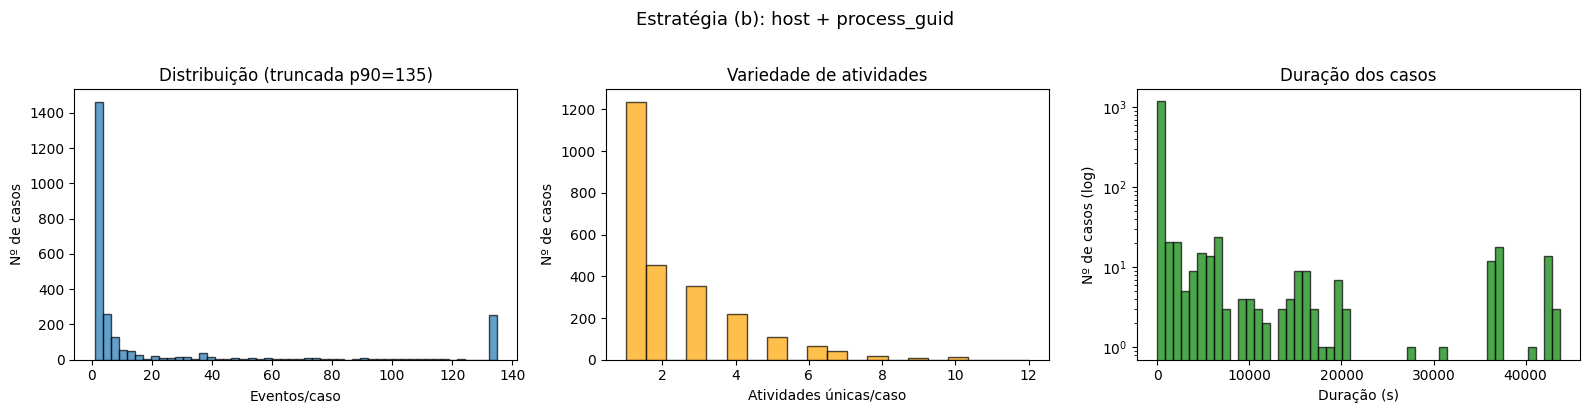

In [54]:
# === DISTRIBUIÇÃO DE EVENTOS POR CASO (visual rápido) ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# histograma truncado no p99
p90 = case_stats["n_events"].quantile(0.90)
axes[0].hist(case_stats["n_events"].clip(upper=p99), bins=50, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Eventos/caso")
axes[0].set_ylabel("Nº de casos")
axes[0].set_title(f"Distribuição (truncada p90={p99:.0f})")

# atividades por caso
axes[1].hist(
    case_stats["n_unique_activities"].clip(upper=20),
    bins=20,
    edgecolor="k",
    alpha=0.7,
    color="orange",
)
axes[1].set_xlabel("Atividades únicas/caso")
axes[1].set_ylabel("Nº de casos")
axes[1].set_title("Variedade de atividades")

# duração dos casos (log scale, sem zeros)
dur_nonzero = case_stats.loc[case_stats["duration_s"] > 0, "duration_s"]
if len(dur_nonzero) > 0:
    axes[2].hist(
        dur_nonzero.apply(lambda x: max(x, 0.001)),
        bins=50,
        edgecolor="k",
        alpha=0.7,
        color="green",
        log=True,
    )
    axes[2].set_xlabel("Duração (s)")
    axes[2].set_ylabel("Nº de casos (log)")
    axes[2].set_title("Duração dos casos")

plt.suptitle("Estratégia (b): host + process_guid", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(
    "Comiset23_Lab_Dataset/strategy_b_overview.png", dpi=150, bbox_inches="tight"
)
plt.show()

DFG salvo em `strategy_b_dfg.png`


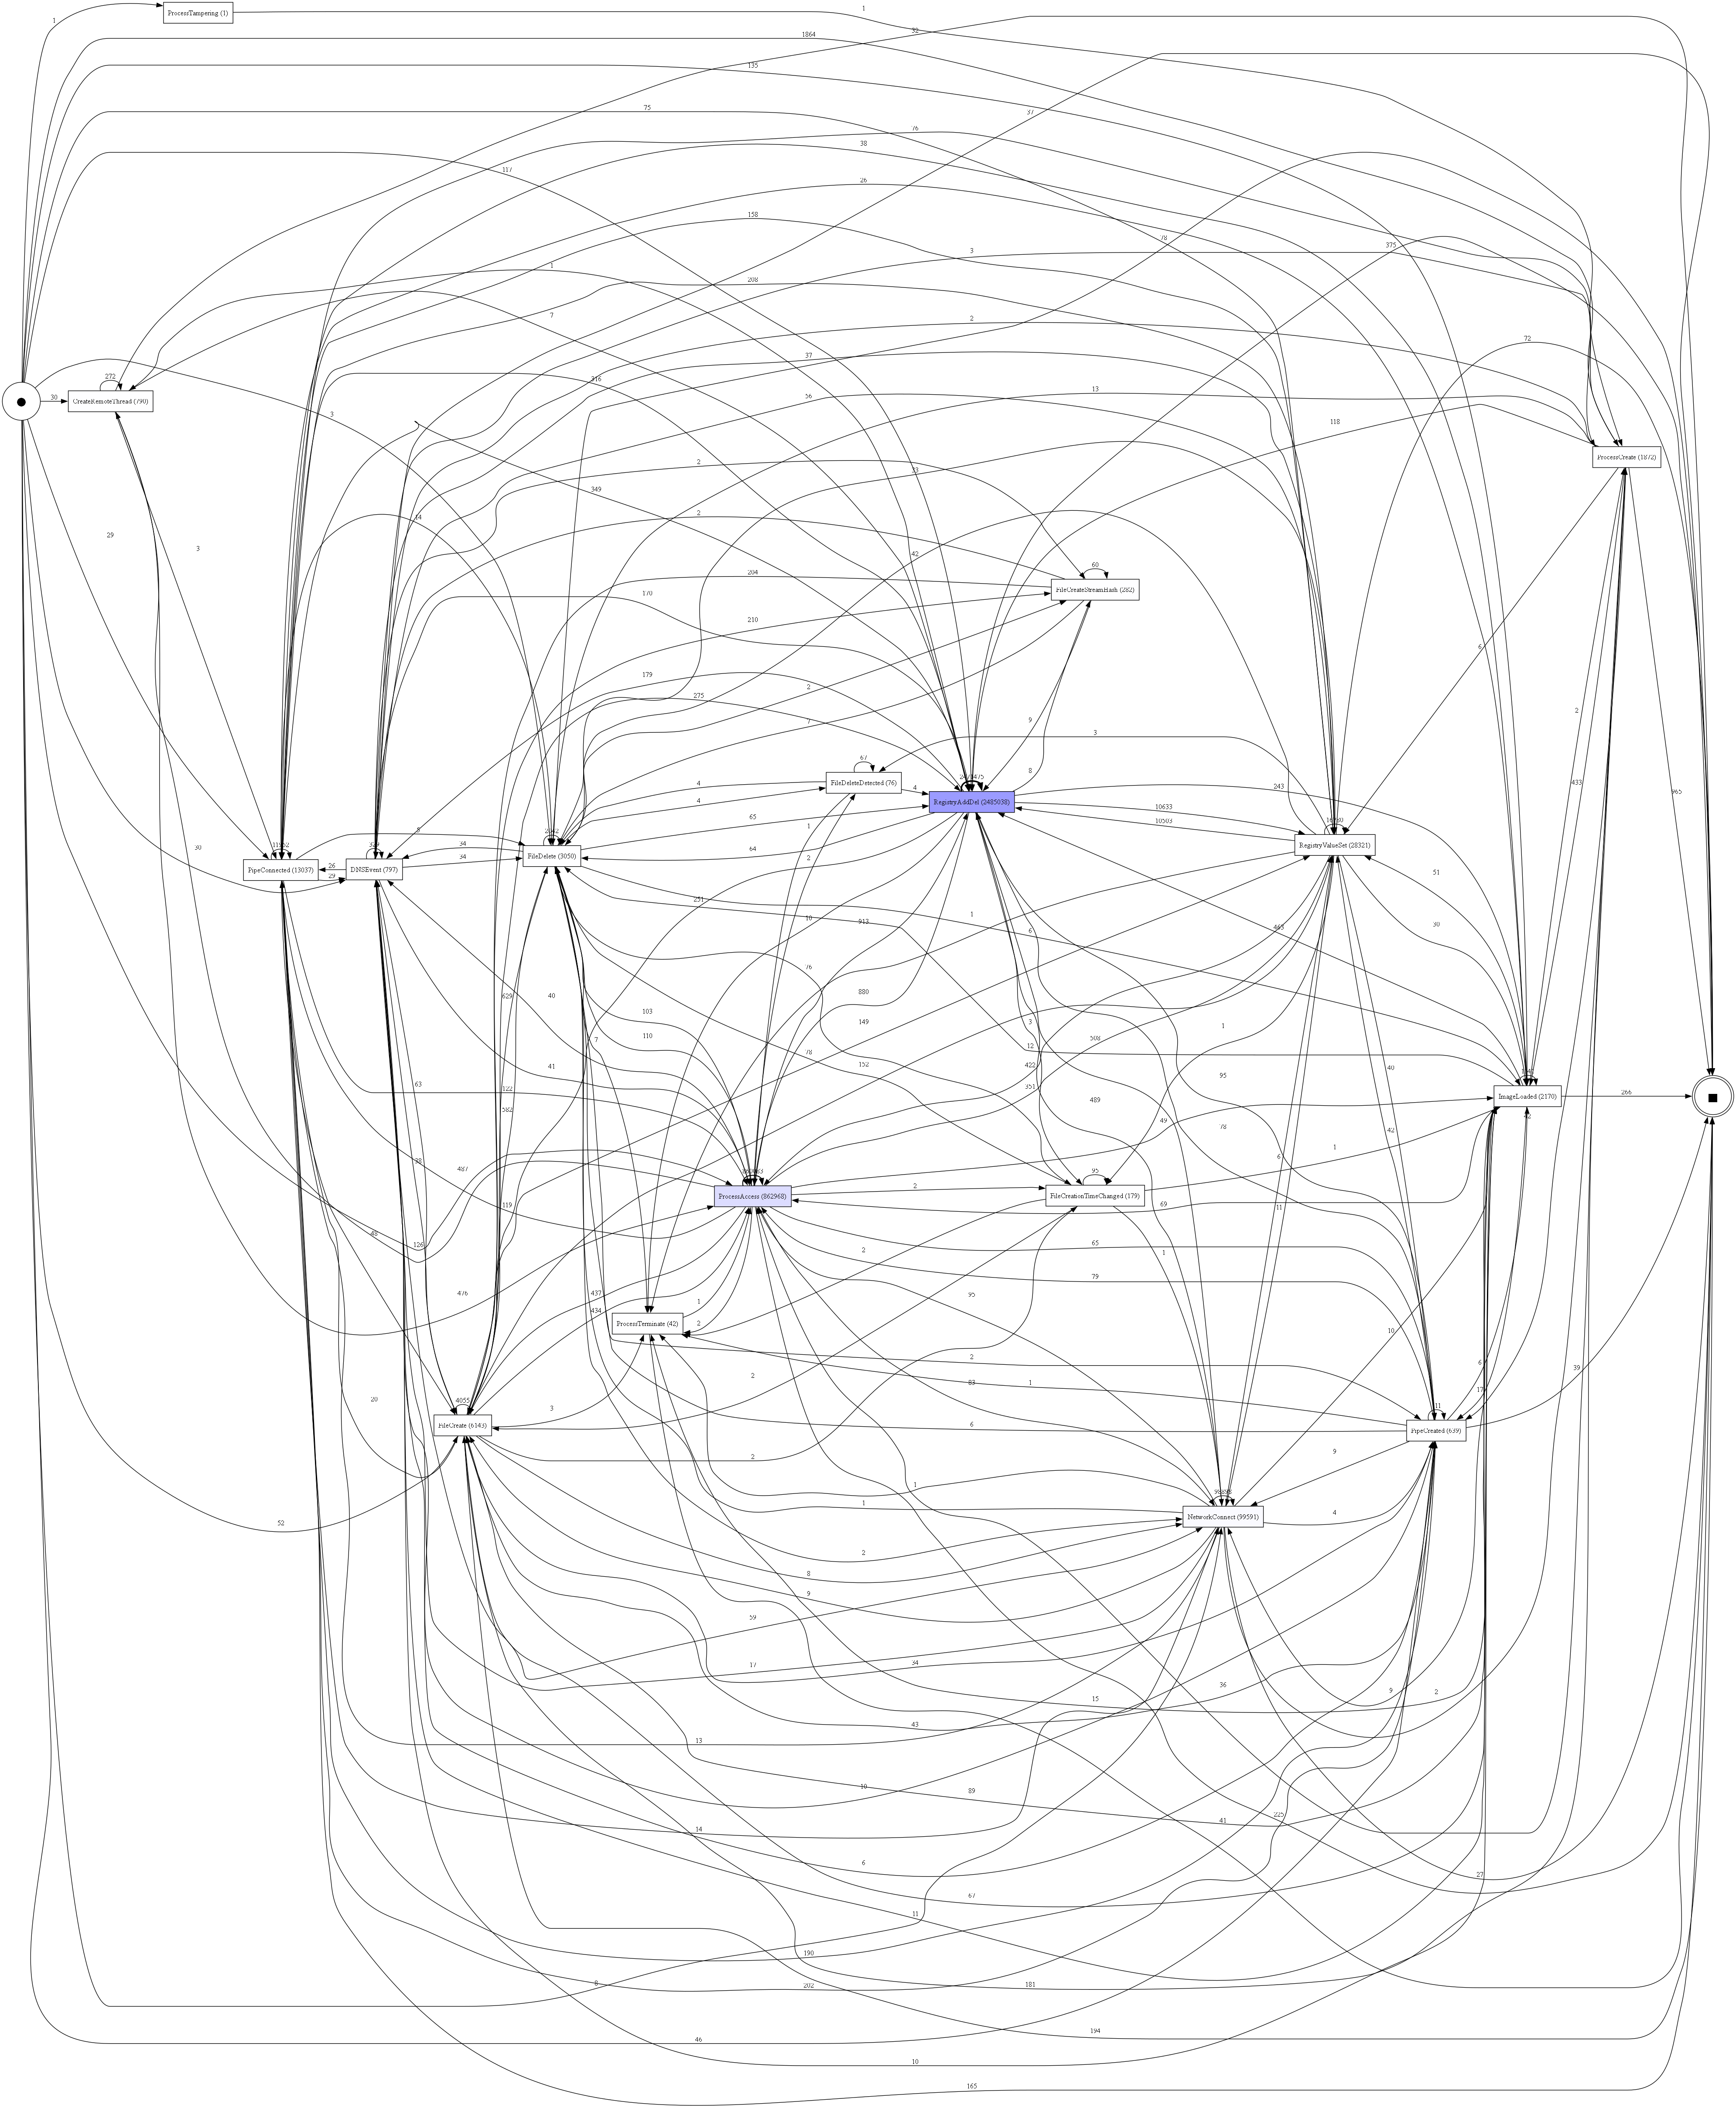

In [61]:
# === PM4PY: formatar e gerar DFG ===
import pm4py

# pm4py espera colunas com nomes específicos
lab_b_pm = lab_b.rename(
    columns={
        "case_id": "case:concept:name",
        "activity": "concept:name",
        "timestamp": "time:timestamp",
    }
)

# DFG (Directly-Follows Graph) - visão geral do fluxo
dfg, start_activities, end_activities = pm4py.discover_dfg(lab_b_pm)

# Salvar como imagem
pm4py.save_vis_dfg(
    dfg, start_activities, end_activities, "Comiset23_Lab_Dataset/strategy_b_dfg.png"
)
print("DFG salvo em `strategy_b_dfg.png`")

# Mostrar no notebook (se suportado)
pm4py.view_dfg(dfg, start_activities, end_activities)

In [67]:
# top 10 transições mais frequentes (pra entender o padrão dominante)
for (a, b), freq in sorted(dfg.items(), key=lambda x: -x[1])[:10]:
    print(f"  {a:30s} -> {b:30s}  {freq:>8,}")

  RegistryAddDel                 -> RegistryAddDel                  2,471,475
  ProcessAccess                  -> ProcessAccess                    860,083
  NetworkConnect                 -> NetworkConnect                    98,898
  RegistryValueSet               -> RegistryValueSet                  16,780
  PipeConnected                  -> PipeConnected                     11,952
  RegistryAddDel                 -> RegistryValueSet                  10,633
  RegistryValueSet               -> RegistryAddDel                    10,503
  FileCreate                     -> FileCreate                         4,055
  FileDelete                     -> FileDelete                         2,042
  ImageLoaded                    -> ImageLoaded                        1,141


#### Salvar b) em arquivo

In [65]:
t0 = time.perf_counter()

OUT_DIR = "Comiset23_Lab_Dataset"

pq_path = f"{OUT_DIR}/lab_b_eventlog.parquet"
lab_b.to_parquet(pq_path, index=False)

# XES via r4pm (leitura por ProM, Disco, pm4py)
xes_path = f"{OUT_DIR}/lab_b_eventlog.xes"
pm4py.write_xes(
    lab_b_pm,
    xes_path,
    case_id_key="case:concept:name",
    activity_key="concept:name",
    timestamp_key="time:timestamp",
)

elapsed = time.perf_counter() - t0
pq_mb = os.path.getsize(pq_path) / 1e6
xes_mb = os.path.getsize(xes_path) / 1e6
print(f"Artefatos salvos ({elapsed:.1f}s):")
print(f"  {pq_path:45s}  {pq_mb:>7.1f} MB")

Artefatos salvos (88.1s):
  Comiset23_Lab_Dataset/lab_b_eventlog.parquet      20.6 MB
  Comiset23_Lab_Dataset/lab_b_eventlog.xes        2415.5 MB


#### Carregar b) de arquivo

In [15]:
lab_b = pd.read_parquet("Comiset23_Lab_Dataset/lab_b_eventlog.parquet")

,case_id,activity,timestamp,host_name,process_guid,process_name,process_path,process_id,process_parent_guid,process_parent_name,process_parent_id,event_id,source_name,_channel,rule_technique_id,rule_technique_name,is_malicious
0,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
1,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
2,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
4,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-63...,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3504991,desktop-4pvps6e.phoenix.local|4FD6B357-3669-63...,NetworkConnect,2022-11-16 23:54:00.180000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504992,desktop-4pvps6e.phoenix.local|4FD6B357-3669-63...,NetworkConnect,2022-11-16 23:54:00.181000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504993,desktop-4pvps6e.phoenix.local|4FD6B357-3669-63...,NetworkConnect,2022-11-16 23:55:04.055000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504994,desktop-4pvps6e.phoenix.local|4FD6B357-DB03-63...,DNSEvent,2022-11-16 23:56:07.854000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-DB03-6375-8602-000000002900,setuphost.exe,c:\\$windows.~bt\\sources\\setuphost.exe,3312,<NA>,<NA>,<NA>,22,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False


In [68]:
# === RESUMO ===
print(f"""
ESTRATÉGIA (b): host + process_guid
{"=" * 50}
Dados de entrada:     `lab_d1_flat` ({len(lab_flat):,} eventos, {len(lab_flat.columns):,} colunas)
Event log resultante: `lab_b` ({len(lab_b):,} eventos, {lab_b["case_id"].nunique():,} casos)
Atividades (A1):      {lab_b["activity"].nunique()} tipos Sysmon
Cobertura:            {cobertura:.2%}
Fragmentação:         {fragmentacao:.2%}
Coesão Estrutural:    {coesao_estrutural:.4f}

Próximos passos:
  1. Repetir para estratégias (a), (c), (d)
  2. Comparar métricas entre estratégias
  3. Process Discovery (Inductive Miner) na melhor
  4. PPM com skpm: next-activity prediction (Macro-F1)
""")


ESTRATÉGIA (b): host + process_guid
Dados de entrada:     `lab_d1_flat` (3,524,864 eventos, 670 colunas)
Event log resultante: `lab_b` (3,504,996 eventos, 2,516 casos)
Atividades (A1):      17 tipos Sysmon
Cobertura:            99.44%
Fragmentação:         43.96%
Coesão Estrutural:    0.0000

Próximos passos:
  1. Repetir para estratégias (a), (c), (d)
  2. Comparar métricas entre estratégias
  3. Process Discovery (Inductive Miner) na melhor
  4. PPM com skpm: next-activity prediction (Macro-F1)



### Estratégia c) - `host`+`time_window`

> TO-DO